# CSCI 333 — Homework 3: Simulating Modified Slotted-Aloha

This notebook contains the solution to all four tasks.

**Modules used:** `random` (Task 1 & 2), `pickle` and `matplotlib` (Task 3). No other modules are imported.

## Task 1 — Implementation of the modified slotted-Aloha protocol

We represent each node as a small class that tracks:

* `p` — current transmission probability for the frame it is trying to send;
* `collisions` — number of consecutive collisions the *current* frame has experienced;
* `idle_cnt`, `tx_cnt`, `drop_cnt` — cumulative counters requested by the logging format.

At the start of every slot each node generates one random number `r` in `[0, 1)` and
transmits (state `tx`) if `r < p`, otherwise it stays `idle`. After the slot the simulator
looks at how many nodes transmitted and:

* 0 transmitters  → **idle** slot — no state change;
* 1 transmitter   → **success** slot — the transmitting node gets a new frame (`p = p0`,
  `collisions = 0`);
* ≥2 transmitters → **collision** slot — every transmitting node increments its
  collision counter, halves its `p` and, after the 4th consecutive collision, drops the
  frame and resets `p = p0`.

Because each node's buffer is always full, a success or a drop immediately produces a new
frame to transmit starting at probability `p0`.

In [1]:
import random


class Node:
    """A single node participating in the modified slotted-Aloha protocol."""

    def __init__(self, node_id, p_0):
        self.id = node_id
        self.p_0 = p_0
        self.p = p_0
        self.collisions = 0
        self.state = 'idle'
        self.idle_cnt = 0
        self.tx_cnt = 0
        self.succ_cnt = 0
        self.drop_cnt = 0

    def decide(self):
        """Decide whether the node transmits in the current slot."""
        r = random.random()
        self.state = 'tx' if r < self.p else 'idle'
        if self.state == 'tx':
            self.tx_cnt += 1
        else:
            self.idle_cnt += 1
        return self.state

    def on_success(self):
        self.succ_cnt += 1
        self.p = self.p_0
        self.collisions = 0

    def on_collision(self):
        self.collisions += 1
        if self.collisions >= 4:
            self.drop_cnt += 1
            self.p = self.p_0
            self.collisions = 0
        else:
            self.p = self.p / 2


def simulate_slotted_aloha(num_slots, n, p_0, logging=False):
    """Simulate the modified slotted-Aloha protocol.

    Arguments
    ---------
    num_slots : int
        Total number of slots (simulation duration).
    n : int
        Number of nodes in the network.
    p_0 : float
        Transmission probability for a brand-new frame.
    logging : bool, optional
        If True, prints a status line for every node every 10 slots.

    Returns
    -------
    float
        Efficiency = (# success slots) / num_slots.
    """

    nodes = [Node(i, p_0) for i in range(n)]
    success_slots = 0

    if logging:
        print(f'Simulation with {num_slots} slots, {n} nodes, and p_0 of {p_0}')

    for slot in range(num_slots):
        transmitters = [node for node in nodes if node.decide() == 'tx']

        if len(transmitters) == 0:
            slot_status = 'idle'
        elif len(transmitters) == 1:
            slot_status = 'success'
            success_slots += 1
            transmitters[0].on_success()
        else:
            slot_status = 'collision'
            for node in transmitters:
                node.on_collision()

        if logging and slot % 10 == 0:
            print(f'Slot {slot}: {slot_status}')
            for node in nodes:
                print(
                    f'  {node.id:>2}: {node.state:>4}, '
                    f'p: {str(node.p):>6}, '
                    f'idle_cnt: {node.idle_cnt:>4}, '
                    f'tx_cnt: {node.tx_cnt:>4}, '
                    f'succ_cnt: {node.succ_cnt:>4}, '
                    f'drop_cnt: {node.drop_cnt}'
                )

    efficiency = success_slots / num_slots
    if logging:
        print(f'n={n}, p_0={p_0}, efficiency={efficiency}')
    return efficiency


## Task 2 — Verifying the logs

Call `simulate_slotted_aloha(50, 5, 0.5, True)` and check that the log format is correct.
Exact output depends on the random seed, but the format matches the assignment's example.

In [2]:
random.seed(0)
simulate_slotted_aloha(50, 5, 0.5, True)

Simulation with 50 slots, 5 nodes, and p_0 of 0.5
Slot 0: collision
   0: idle, p:    0.5, idle_cnt:    1, tx_cnt:    0, succ_cnt:    0, drop_cnt: 0
   1: idle, p:    0.5, idle_cnt:    1, tx_cnt:    0, succ_cnt:    0, drop_cnt: 0
   2:   tx, p:   0.25, idle_cnt:    0, tx_cnt:    1, succ_cnt:    0, drop_cnt: 0
   3:   tx, p:   0.25, idle_cnt:    0, tx_cnt:    1, succ_cnt:    0, drop_cnt: 0
   4: idle, p:    0.5, idle_cnt:    1, tx_cnt:    0, succ_cnt:    0, drop_cnt: 0
Slot 10: collision
   0: idle, p:   0.25, idle_cnt:    5, tx_cnt:    6, succ_cnt:    3, drop_cnt: 0
   1:   tx, p:   0.25, idle_cnt:    8, tx_cnt:    3, succ_cnt:    1, drop_cnt: 0
   2:   tx, p:  0.125, idle_cnt:    9, tx_cnt:    2, succ_cnt:    0, drop_cnt: 0
   3: idle, p:  0.125, idle_cnt:    9, tx_cnt:    2, succ_cnt:    0, drop_cnt: 0
   4: idle, p:   0.25, idle_cnt:   10, tx_cnt:    1, succ_cnt:    0, drop_cnt: 0
Slot 20: collision
   0: idle, p:    0.5, idle_cnt:   12, tx_cnt:    9, succ_cnt:    5, drop_cnt: 0
   

0.44

## Task 3 — Performance evaluation

We sweep the simulator over every combination of

* `n ∈ {1, 2, 5, 10, 20, 50, 100}`, and
* `p_0 ∈ {0, 0.01, 0.02, …, 0.09, 0.1, 0.2, …, 0.9, 1.0}`,

with `num_slots = 100000` and `logging=False`, and plot the simulation efficiency on the
same axes as the theoretical values loaded from `theoretical_efficiency.pkl`.

theoretical_efficiency.pkl not found next to the notebook; the plot will show simulation curves only. Place the file provided by the instructor in this folder and re-run this cell to overlay the theoretical curves.


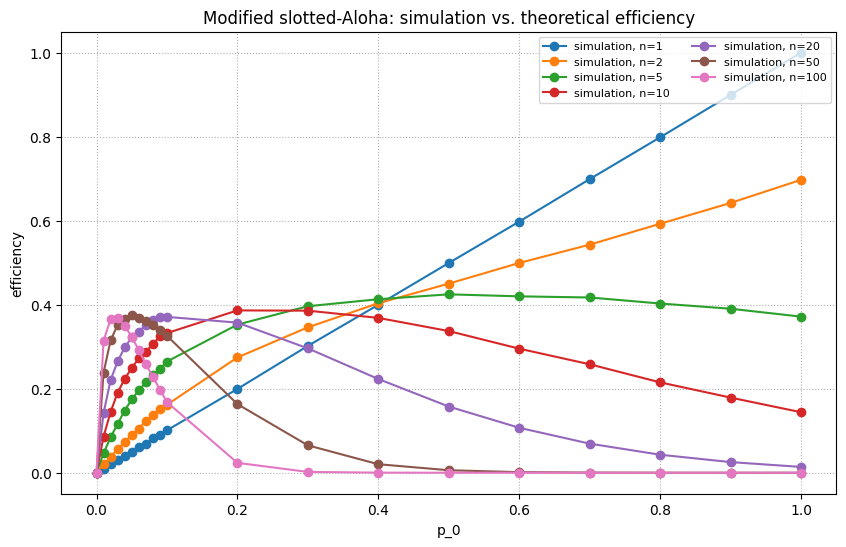

In [3]:
import pickle
import matplotlib.pyplot as plt

num_slots = 100_000
n_values = [1, 2, 5, 10, 20, 50, 100]
p_values = [round(0.01 * i, 2) for i in range(0, 10)] + [round(0.1 * i, 1) for i in range(1, 11)]

random.seed(42)

sim_efficiency = {}
for n in n_values:
    sim_efficiency[n] = []
    for p in p_values:
        eff = simulate_slotted_aloha(num_slots, n, p, False)
        sim_efficiency[n].append(eff)

try:
    with open('theoretical_efficiency.pkl', 'rb') as f:
        theoretical_raw = pickle.load(f)
except FileNotFoundError:
    print('theoretical_efficiency.pkl not found next to the notebook; '
          'the plot will show simulation curves only.')
    theoretical_raw = None

if isinstance(theoretical_raw, dict):
    sample_key = next(iter(theoretical_raw))
    sample_val = theoretical_raw[sample_key]
    print(f'theoretical_efficiency.pkl loaded: type={type(theoretical_raw).__name__}, '
          f'len={len(theoretical_raw)}, sample key={sample_key!r}, '
          f'sample value type={type(sample_val).__name__}')


def get_theoretical(n, p):
    """Return theoretical efficiency for (n, p) regardless of how the pickle is laid out."""
    if theoretical_raw is None:
        return None
    if isinstance(theoretical_raw, dict):
        if (n, p) in theoretical_raw:
            return theoretical_raw[(n, p)]
        if n in theoretical_raw:
            sub = theoretical_raw[n]
            if isinstance(sub, dict):
                if p in sub:
                    return sub[p]
                for k, v in sub.items():
                    if abs(float(k) - p) < 1e-9:
                        return v
                return None
            if hasattr(sub, '__len__') and len(sub) == len(p_values):
                return sub[p_values.index(p)]
            return None
    return None


plt.figure(figsize=(10, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
          'tab:purple', 'tab:brown', 'tab:pink']

for color, n in zip(colors, n_values):
    plt.plot(p_values, sim_efficiency[n], linestyle='-', linewidth=1.2,
             color=color, label=f'simulation, n={n}')
    if theoretical_raw is not None:
        theo = [get_theoretical(n, p) for p in p_values]
        if all(v is not None for v in theo):
            plt.plot(p_values, theo, marker='o', linestyle='None',
                     markersize=3, color=color, label=f'theoretical, n={n}')
        else:
            print(f'Could not match theoretical values for n={n}; '
                  'check the pickle structure.')

plt.xlabel('p_0')
plt.ylabel('efficiency')
plt.title('Modified slotted-Aloha: simulation vs. theoretical efficiency')
plt.grid(True, linestyle=':')
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.show()

## Task 4 — Hand-drawn diagram: written explanation

The hand-drawn figure (`lastname_firstname.jpg`) shows 10 slots of the modified
slotted-Aloha protocol with **four nodes (A, B, C, D)** and **p_0 = 1**. Because p_0 = 1
every new frame is guaranteed to be transmitted in its very first slot, so we see the
retransmission / halving / drop logic very clearly. For each slot the diagram shows the
random number each node generated, the value of `p` that node held *entering* that slot,
whether the node transmitted, and the resulting slot type (idle / success / collision).

A walk-through of the 10 slots in the diagram:

* **Slot 1 — collision.** All four nodes have `p = 1` (their first frame). Every random
  number is smaller than 1, so A, B, C and D all transmit. Four transmitters means a
  collision; each node halves its probability to `p = 1/2` and its collision counter
  becomes 1.
* **Slot 2 — collision.** With `p = 1/2`, nodes A and C happen to draw `r < 0.5` while B
  and D draw `r ≥ 0.5`. A and C transmit and collide. Their `p` halves to `1/4` and
  their collision counters become 2. B and D stayed idle, so their `p` is unchanged at
  `1/2`.
* **Slot 3 — success.** A draws `r ≥ 1/4` (idle), B draws `r < 1/2` (tx), C draws
  `r ≥ 1/4` (idle), D draws `r ≥ 1/2` (idle). Only B transmits → success. B finishes its
  frame, gets a new one, and resets to `p = p_0 = 1`.
* **Slot 4 — collision.** B now transmits with probability 1 and does so. A and C still
  hold `p = 1/4` and happen to draw small enough numbers to transmit. Three transmitters
  → collision. A and C reach collision counter 3 and their `p` drops to `1/8`; B reaches
  collision counter 1 and goes to `p = 1/2`.
* **Slot 5 — idle.** A and C both draw `r ≥ 1/8`, B draws `r ≥ 1/2`, D draws `r ≥ 1/2`.
  No one transmits. All probabilities are unchanged.
* **Slot 6 — collision.** A draws `r < 1/8` (tx), C draws `r < 1/8` (tx), B and D stay
  idle. A and C collide for the 4th consecutive time, so each **drops** its current
  frame, increments `drop_cnt` and resets `p = 1`. B and D keep `p = 1/2`.
* **Slot 7 — collision.** With their fresh frames A and C both have `p = 1` and both
  transmit. D also happens to draw `r < 1/2` and transmits. Three transmitters →
  collision. A, C go to `p = 1/2` (collision counter 1); D goes to `p = 1/4` (its
  collision counter becomes 2 because it had already collided once before).
* **Slot 8 — success.** Only D draws a number below its `p = 1/4`; A, B, C are idle. D's
  frame succeeds, so D resets to `p = 1` with a fresh frame.
* **Slot 9 — collision.** D transmits (probability 1) and B transmits (draws
  `r < 1/2`). The two collide. D → `p = 1/2` (collision counter 1); B → `p = 1/4`
  (collision counter 2).
* **Slot 10 — success.** Only A draws `r < 1/2` and transmits; everyone else stays idle.
  A's frame succeeds and A resets to `p = 1`.

Counts of slot types over the 10 slots: **idle = 1, success = 3, collision = 6**, so the
efficiency of this tiny run is `3 / 10 = 0.3`. The diagram also demonstrates all three
key behaviours of the protocol: repeated halving of `p` after collisions (slots 1, 2, 4,
7, 9), resetting `p` to `p_0` after a success (slots 3, 8, 10), and the *drop* event that
happens after four consecutive collisions on the same frame (slot 6).

> Replace this section with the narrative that matches your own drawing if the exact
> random numbers or slot outcomes differ. The structure above (slot number → who
> transmitted and why → resulting slot type → how each node's `p` and collision counter
> change) is what needs to be present.